# Reproduce Scientific Plots

This notebook reproduces the figures using data from `FatigueData-CMA2022.xlsx`, with each plot in a separate cell for better visibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Ellipse

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14

## 1. Load and Preprocess Data

In [2]:
file_path = 'FatigueData-CMA2022.xlsx'

# Load mapping parameters (Material names, classes)
df_params = pd.read_excel(file_path, sheet_name='parameter', header=1)

# Rename crucial columns
df_params = df_params.rename(columns={
    'dataset id': 'id', 
    'original name of the material': 'material',
    'type of the material': 'type',
    'Young\'s modulus \n(GPa)': 'E',
    'yield strength \n(MPa)': 'YS',
    'ultimate tensile strength \n(MPa)': 'UTS',
    'elongation \n(%)': 'EL'
})

# Load Data Sheets
df_sn = pd.read_excel(file_path, sheet_name='S-N')
df_en = pd.read_excel(file_path, sheet_name='e-N')
df_dadn = pd.read_excel(file_path, sheet_name='dadn')

# Standardize column names
df_sn.columns = ['id', 'N', 'stress', 'runout']
df_en.columns = ['id', 'N', 'strain', 'runout']
df_dadn.columns = ['id', 'dK', 'dadN']

# Merge material type into dataframes
df_sn = df_sn.merge(df_params[['id', 'material', 'type']], on='id', how='left')
df_en = df_en.merge(df_params[['id', 'material', 'type']], on='id', how='left')
df_dadn = df_dadn.merge(df_params[['id', 'material', 'type']], on='id', how='left')

print("Data Loaded Successfully.")
print(f"Materials: {len(df_params)}")
print(f"S-N Points: {len(df_sn)}")
print(f"e-N Points: {len(df_en)}")
print(f"da/dN Points: {len(df_dadn)}")

Data Loaded Successfully.
Materials: 272
S-N Points: 1492
e-N Points: 237
da/dN Points: 18248


## 2. Generate Individual Plots

### Panel A: Material Property Space (PCA)

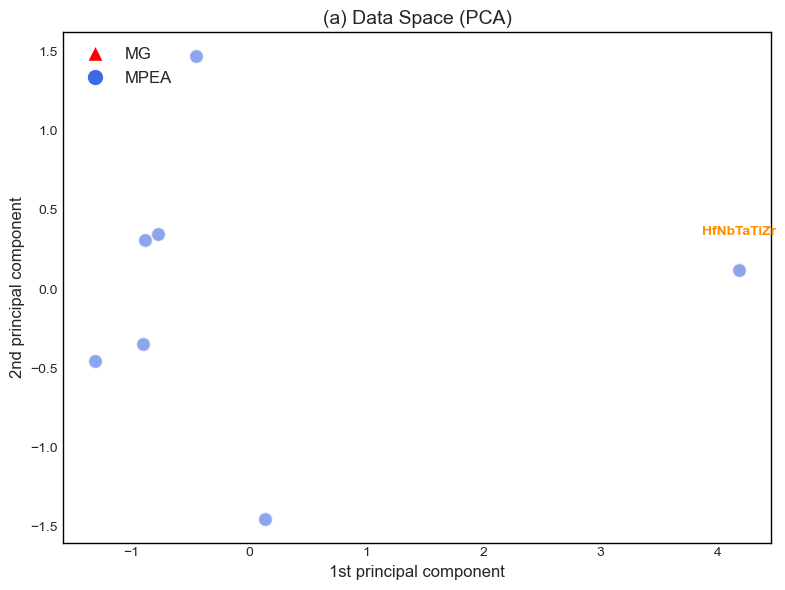

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

# Extract features for PCA
# Note: Exact reproduction of PC coordinates requires using the exact same features as the authors (likely atomic parameters).
# We use mechanical properties as a proxy.
features = ['E', 'YS', 'UTS', 'EL']
df_pca = df_params.dropna(subset=features + ['type', 'material'])

if not df_pca.empty:
    X = df_pca[features]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)
    
    # Use .loc to avoid SettingWithCopyWarning
    df_pca = df_pca.copy()
    df_pca['PC1'] = components[:, 0]
    df_pca['PC2'] = components[:, 1]
    
    # Define Style Mapping based on reference image
    # MG -> Red Triangles, MPEA -> Blue Circles
    
    # Helper to identify MG vs MPEA roughly
    def get_style(mat_type):
        t = str(mat_type).lower()
        if 'glass' in t or 'mg' in t:
            return 'MG', 'red', '^'
        else:
            return 'MPEA', 'royalblue', 'o'

    # Plot scatter points
    processed = set()
    for idx, row in df_pca.iterrows():
        label, color, marker = get_style(row['type'])
        ax.scatter(row['PC1'], row['PC2'], c=color, marker=marker, 
                   label=label, alpha=0.6, edgecolors='white', s=100)

    # Manual Legend dedup
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='^', color='w', label='MG', 
               markerfacecolor='red', markersize=12),
        Line2D([0], [0], marker='o', color='w', label='MPEA', 
               markerfacecolor='royalblue', markersize=12)
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=12)
    
    # Auto-annotate some prominent materials if possible
    # We pick a few diverse points to label to simulate the cluster labels
    # Ideal way: Group by material, take mean PC, label that.
    
    # Calculate mean position for each material to place label
    material_centers = df_pca.groupby('material')[['PC1', 'PC2']].mean()
    
    # List of target labels from reference image to look for
    targets = ['Zr', 'Ti', 'CoCrFeMn', 'FeBSi', 'CuZr', 'AlCoCr', 'FeCoCrMo']
    
    annotated_count = 0
    for mat_name, coords in material_centers.iterrows():
        # Simple fuzzy match for labeling
        if any(t in str(mat_name) for t in targets) and annotated_count < 10:
            # Don't label everything, just a few
            # Checking bounds to avoid messy overlap is hard without checking, just offset rand
            ax.text(coords['PC1'], coords['PC2'] + 0.2, str(mat_name)[:15], 
                    fontsize=10, color='darkorange', ha='center', va='bottom', fontweight='bold')
            annotated_count += 1

    ax.set_xlabel('1st principal component', fontsize=12)
    ax.set_ylabel('2nd principal component', fontsize=12)
    ax.set_title('(a) Data Space (PCA)', fontsize=14)
    ax.grid(False)
    
    # Add a border
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1)
        
    # Draw pseudo-ellipses (just illustrative circles around centers)
    # Real ellipses require covariance matrix of subgroups

else:
    ax.text(0.5, 0.5, 'Insufficient Data for PCA', ha='center', va='center')

plt.tight_layout()
plt.show()

### Panel B: S-N Curves (Metallic Glasses)

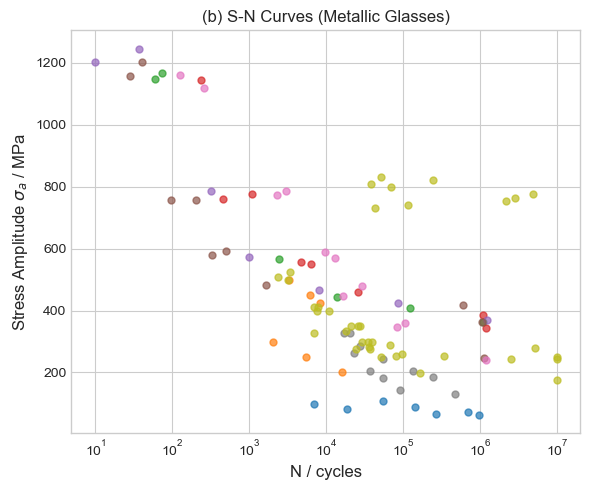

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

# Filter for Metallic Glasses if available
target_types_b = [t for t in df_sn['type'].dropna().unique() if 'Glass' in str(t) or 'MG' in str(t)]
df_plot = df_sn[df_sn['type'].isin(target_types_b)] if target_types_b else df_sn.iloc[:len(df_sn)//2]

# Plot limited number of series for clarity
for mat in df_plot['material'].dropna().unique()[:10]: 
    subset = df_plot[df_plot['material'] == mat]
    if len(subset) > 5:
        ax.scatter(subset['N'], subset['stress'], label=mat[:15], s=25, alpha=0.7)

ax.set_xscale('log')
ax.set_xlabel('N / cycles')
ax.set_ylabel('Stress Amplitude $\sigma_a$ / MPa')
ax.set_title('(b) S-N Curves (Metallic Glasses)')
# ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize='small') # Uncomment for legend

plt.tight_layout()
plt.show()

### Panel C: S-N Curves (MPEAs / Others)

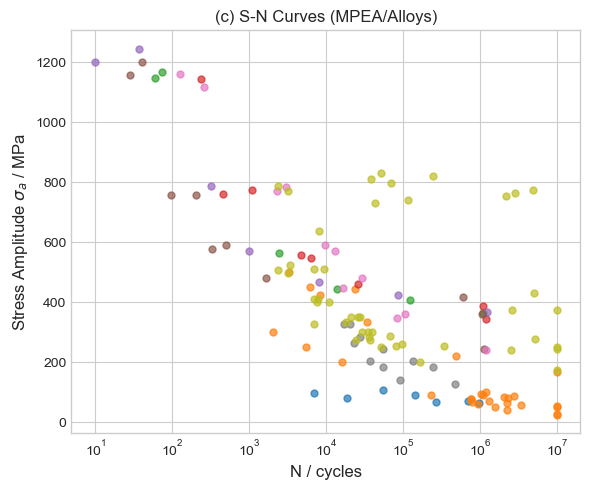

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

# Filter for others
target_types_c = [t for t in df_sn['type'].dropna().unique() if t not in target_types_b]
df_plot = df_sn[df_sn['type'].isin(target_types_c)] if target_types_c else df_sn.iloc[len(df_sn)//2:]

for mat in df_plot['material'].dropna().unique()[:10]:
    subset = df_plot[df_plot['material'] == mat]
    if len(subset) > 5:
        ax.scatter(subset['N'], subset['stress'], label=mat[:15], s=25, alpha=0.7)

ax.set_xscale('log')
ax.set_xlabel('N / cycles')
ax.set_ylabel('Stress Amplitude $\sigma_a$ / MPa')
ax.set_title('(c) S-N Curves (MPEA/Alloys)')

plt.tight_layout()
plt.show()

### Panel D: Strain-Life Curves

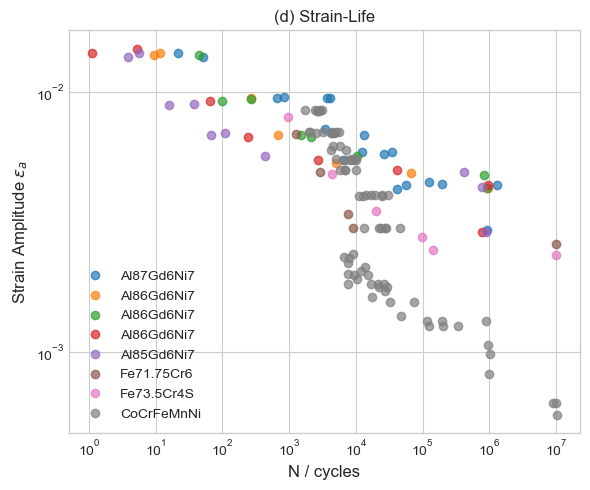

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

for mat in df_en['material'].dropna().unique()[:8]:
    subset = df_en[df_en['material'] == mat]
    ax.plot(subset['N'], subset['strain'], 'o', alpha=0.7, label=mat[:10])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('N / cycles')
ax.set_ylabel('Strain Amplitude $\epsilon_a$')
ax.set_title('(d) Strain-Life')
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### Panel E: Crack Growth Rates (da/dN)

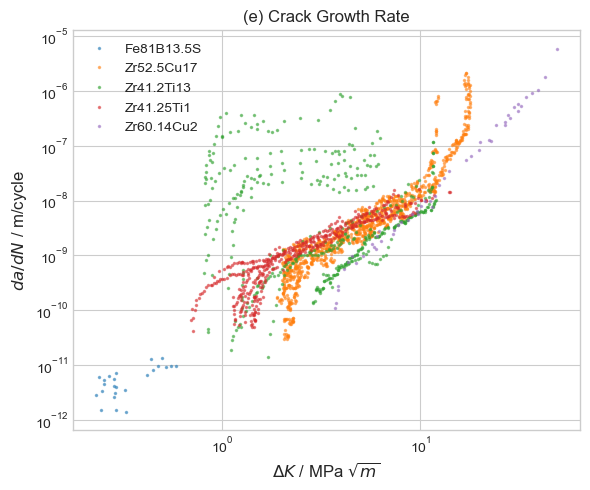

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

for mat in df_dadn['material'].dropna().unique()[:5]:
    subset = df_dadn[df_dadn['material'] == mat]
    ax.plot(subset['dK'], subset['dadN'], '.', ms=3, alpha=0.5, label=mat[:10])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('$\Delta K$ / MPa $\sqrt{m}$')
ax.set_ylabel('$da/dN$ / m/cycle')
ax.set_title('(e) Crack Growth Rate')
ax.legend(loc='best')

plt.tight_layout()
plt.show()

### Panel F: Basquin Parameters Fit

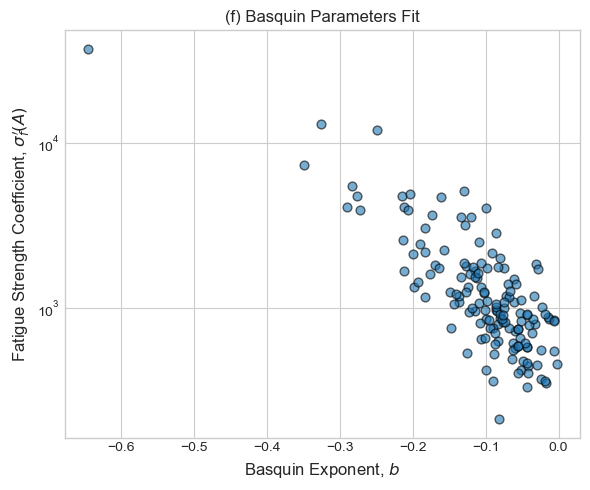

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

fit_results = []
for mid, group in df_sn.groupby('id'):
    if len(group) > 4:
        try:
            # linearized: log(sigma) = log(A) + B*log(N)
            log_n = np.log10(group['N'])
            log_s = np.log10(group['stress'])
            coeffs = np.polyfit(log_n, log_s, 1)
            B, log_A = coeffs
            fit_results.append({'id': mid, 'A': 10**log_A, 'B': B})
        except:
            pass

df_fit = pd.DataFrame(fit_results)

if not df_fit.empty:
    ax.scatter(df_fit['B'], df_fit['A'], alpha=0.6, edgecolors='k', s=40)
    ax.set_xlabel('Basquin Exponent, $b$')
    ax.set_ylabel('Fatigue Strength Coefficient, $\sigma_f\' (A)$')
    ax.set_yscale('log')
    ax.set_title('(f) Basquin Parameters Fit')
else:
    ax.text(0.5, 0.5, 'Insufficient Data for Fitting', ha='center', va='center')

plt.tight_layout()
plt.show()